# [과제4] 스트리밍 알고리즘 비교 실험
2243232 김은서

대용량 데이터 스트림 환경에서 전체 데이터를 저장하지 않고 근사 계산을 수행하는 스트리밍 알고리즘을 구현하고, 정확도·메모리·처리시간을 비교합니다.

- 사용 데이터셋: MovieLens 1M `ratings.dat`
- 레코드 수: 1,000,209개
- 구현 알고리즘: Bloom Filter, Count-Min Sketch
- 스트림 단위: 평점 이벤트 한 줄

In [1]:
# 기본 라이브러리
import os
import time
import math
import random
import zipfile
import urllib.request
from pathlib import Path
from collections import defaultdict

import pandas as pd

DATA_URL = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"
ZIP_PATH = Path("ml-1m.zip")
DATA_DIR = Path("ml-1m")
RATINGS_PATH = DATA_DIR / "ratings.dat"

RANDOM_SEED = 42
random.seed(RANDOM_SEED)


## STEP 01. 데이터 준비


In [2]:
def download_movielens_1m():
    if RATINGS_PATH.exists():
        return

    if not ZIP_PATH.exists():
        urllib.request.urlretrieve(DATA_URL, ZIP_PATH)

    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('.')

    if not RATINGS_PATH.exists():
        raise FileNotFoundError("ratings.dat 파일을 찾지 못했습니다.")

    print(f"데이터 준비 완료: {RATINGS_PATH}")

download_movielens_1m()


데이터 준비 완료: ml-1m/ratings.dat


In [3]:
def rating_stream(path=RATINGS_PATH):
    with open(path, 'r', encoding='latin-1') as f:
        for line in f:
            user_id, movie_id, rating, timestamp = line.strip().split('::')
            yield user_id, movie_id, int(rating), int(timestamp)

# 레코드 수 확인도 파일을 한 줄씩 순회하며 계산
record_count = sum(1 for _ in rating_stream())
print("총 레코드 수:", record_count)


총 레코드 수: 1000209


## STEP 02. 알고리즘 구현

### 2-1. Bloom Filter

Bloom Filter는 원소가 집합에 포함되어 있는지 근사적으로 판단하는 알고리즘입니다.

- 장점: 매우 적은 메모리로 포함 여부를 빠르게 판단
- 단점: False Positive는 발생할 수 있음
- 특징: False Negative는 발생하지 않음

여기서는 `movie_id`가 과거 스트림에서 등장한 적 있는지를 판단하는 문제로 사용합니다.


In [4]:
class BloomFilter:
    def __init__(self, bit_size, hash_count, seed=42):
        self.bit_size = bit_size
        self.hash_count = hash_count
        self.bits = bytearray((bit_size + 7) // 8)
        self.seed = seed

    def _hashes(self, item):
        item = str(item)
        h1 = hash((item, self.seed)) & 0xFFFFFFFFFFFFFFFF
        h2 = hash((self.seed, item, 'salt')) & 0xFFFFFFFFFFFFFFFF
        for i in range(self.hash_count):
            yield (h1 + i * h2 + i * i) % self.bit_size

    def add(self, item):
        for h in self._hashes(item):
            byte_index = h // 8
            bit_index = h % 8
            self.bits[byte_index] |= (1 << bit_index)

    def __contains__(self, item):
        for h in self._hashes(item):
            byte_index = h // 8
            bit_index = h % 8
            if not (self.bits[byte_index] & (1 << bit_index)):
                return False
        return True

    def memory_bytes(self):
        return len(self.bits)


### 2-2. Count-Min Sketch

Count-Min Sketch는 항목별 빈도를 근사 추정하는 알고리즘입니다.

- 장점: 고정된 작은 메모리로 빈도 추정 가능
- 단점: 해시 충돌 때문에 실제 빈도보다 크게 추정될 수 있음
- 특징: 폭(width)이 커질수록 충돌이 줄고, 깊이(depth)가 커질수록 추정 안정성이 높아짐

여기서는 `movie_id`별 평점 이벤트 빈도를 추정합니다.


In [5]:
class CountMinSketch:
    def __init__(self, width, depth, seed=42):
        self.width = width
        self.depth = depth
        self.seed = seed
        self.table = [[0] * width for _ in range(depth)]

    def _hash(self, item, i):
        item = str(item)
        return (hash((item, self.seed, i)) & 0xFFFFFFFFFFFFFFFF) % self.width

    def add(self, item, count=1):
        for i in range(self.depth):
            self.table[i][self._hash(item, i)] += count

    def estimate(self, item):
        return min(self.table[i][self._hash(item, i)] for i in range(self.depth))

    def memory_bytes(self):
        return self.width * self.depth * 8


## STEP 03. Ground Truth 계산

In [6]:
def build_ground_truth(path=RATINGS_PATH):
    exact_movies = set()
    exact_freq = defaultdict(int)

    start = time.perf_counter()
    for _, movie_id, _, _ in rating_stream(path):
        exact_movies.add(movie_id)
        exact_freq[movie_id] += 1
    elapsed = time.perf_counter() - start

    print("Ground Truth 계산 완료")
    print("고유 영화 수:", len(exact_movies))
    print("계산 시간(초):", round(elapsed, 4))
    return exact_movies, exact_freq

exact_movies, exact_freq = build_ground_truth()


Ground Truth 계산 완료
고유 영화 수: 3706
계산 시간(초): 1.7076


## 4. 실험 함수

정확도, 메모리, 처리 시간을 공통 기준으로 측정합니다.


In [7]:
def run_bloom_experiment(bit_size, hash_count, test_negative_count=5000):
    bf = BloomFilter(bit_size=bit_size, hash_count=hash_count)

    start = time.perf_counter()
    stream_count = 0
    for _, movie_id, _, _ in rating_stream():
        bf.add(movie_id)
        stream_count += 1
    elapsed = time.perf_counter() - start

    max_movie_id = max(int(m) for m in exact_movies)
    negative_items = [str(max_movie_id + i + 1) for i in range(test_negative_count)]
    false_positive = sum(1 for item in negative_items if item in bf)
    false_positive_rate = false_positive / test_negative_count

    # 실제 존재하는 항목은 False Negative가 없어야 함
    false_negative = sum(1 for item in exact_movies if item not in bf)

    return {
        'algorithm': 'Bloom Filter',
        'params': f'bit_size={bit_size}, hash_count={hash_count}',
        'accuracy_metric': 'False Positive Rate',
        'error': false_positive_rate,
        'false_negative': false_negative,
        'memory_bytes': bf.memory_bytes(),
        'time_sec': elapsed,
        'throughput_records_per_sec': stream_count / elapsed
    }

def run_cms_experiment(width, depth, top_n_eval=100):
    cms = CountMinSketch(width=width, depth=depth)

    start = time.perf_counter()
    stream_count = 0
    for _, movie_id, _, _ in rating_stream():
        cms.add(movie_id)
        stream_count += 1
    elapsed = time.perf_counter() - start

    # 빈도가 높은 항목 일부를 기준으로 상대오차 평가
    eval_items = sorted(exact_freq.items(), key=lambda x: x[1], reverse=True)[:top_n_eval]
    relative_errors = []
    absolute_errors = []
    for movie_id, true_count in eval_items:
        estimated = cms.estimate(movie_id)
        absolute_error = estimated - true_count
        relative_error = absolute_error / true_count
        absolute_errors.append(absolute_error)
        relative_errors.append(relative_error)

    return {
        'algorithm': 'Count-Min Sketch',
        'params': f'width={width}, depth={depth}',
        'accuracy_metric': f'Mean Relative Error(top {top_n_eval})',
        'error': sum(relative_errors) / len(relative_errors),
        'mean_absolute_error': sum(absolute_errors) / len(absolute_errors),
        'memory_bytes': cms.memory_bytes(),
        'time_sec': elapsed,
        'throughput_records_per_sec': stream_count / elapsed
    }


## 5. 파라미터 비교 실험

선택사항 가산점 항목을 고려하여 각 알고리즘의 파라미터를 변경해 비교합니다.


In [8]:
results = []

# Bloom Filter: 비트 배열 크기와 해시 함수 개수 비교
bloom_params = [
    (2**14, 3),
    (2**16, 4),
    (2**18, 5),
]
for bit_size, hash_count in bloom_params:
    results.append(run_bloom_experiment(bit_size, hash_count))

# Count-Min Sketch: width와 depth 비교
cms_params = [
    (500, 3),
    (1000, 5),
    (2000, 7),
]
for width, depth in cms_params:
    results.append(run_cms_experiment(width, depth))

result_df = pd.DataFrame(results)
result_df['memory_kb'] = result_df['memory_bytes'] / 1024
result_df[['algorithm', 'params', 'accuracy_metric', 'error', 'memory_kb', 'time_sec', 'throughput_records_per_sec']]


,algorithm,params,accuracy_metric,error,memory_kb,time_sec,throughput_records_per_sec
0,Bloom Filter,"bit_size=16384, hash_count=3",False Positive Rate,0.167200,2.00000,2.733750,365874.383488
1,Bloom Filter,"bit_size=65536, hash_count=4",False Positive Rate,0.023200,8.00000,1.896430,527416.693017
2,Bloom Filter,"bit_size=262144, hash_count=5",False Positive Rate,0.004400,32.00000,2.663832,375477.510128
3,Count-Min Sketch,"width=500, depth=3",Mean Relative Error(top 100),0.678354,11.71875,1.434386,697308.176299
4,Count-Min Sketch,"width=1000, depth=5",Mean Relative Error(top 100),0.133339,39.06250,1.870008,534868.919735
5,Count-Min Sketch,"width=2000, depth=7",Mean Relative Error(top 100),0.019854,109.37500,2.353829,424928.576594


## 6. 결과 시각화

오차, 메모리, 처리 시간을 각각 비교합니다.


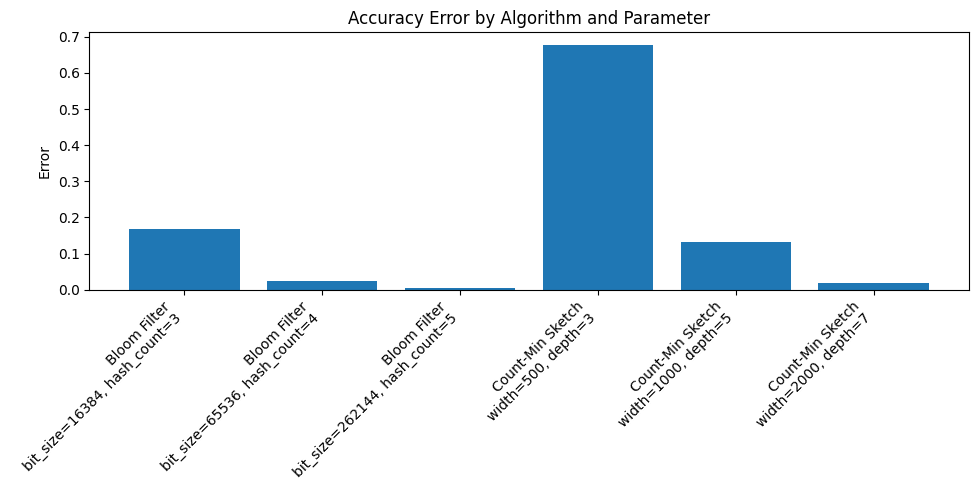

In [9]:
import matplotlib.pyplot as plt

plot_df = result_df.copy()
plot_df['label'] = plot_df['algorithm'] + '\n' + plot_df['params']

plt.figure(figsize=(10, 5))
plt.bar(plot_df['label'], plot_df['error'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Error')
plt.title('Accuracy Error by Algorithm and Parameter')
plt.tight_layout()
plt.show()


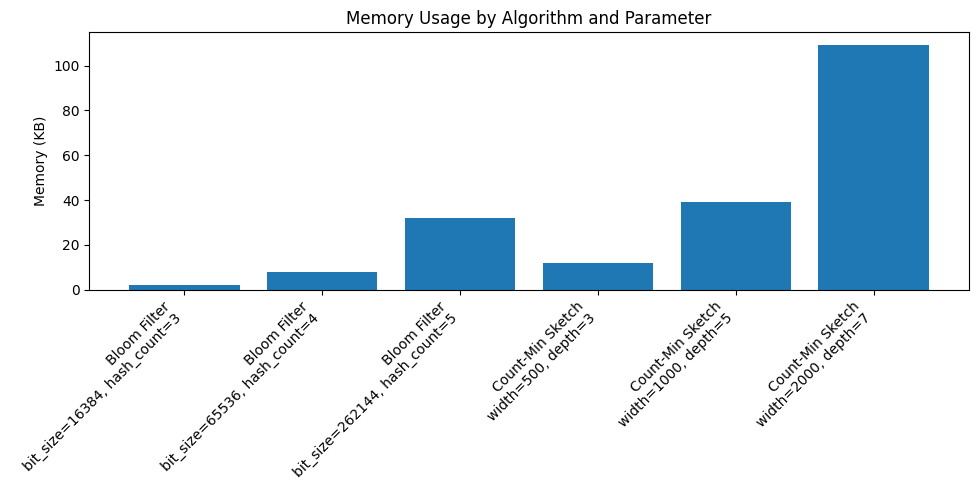

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(plot_df['label'], plot_df['memory_kb'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Memory (KB)')
plt.title('Memory Usage by Algorithm and Parameter')
plt.tight_layout()
plt.show()


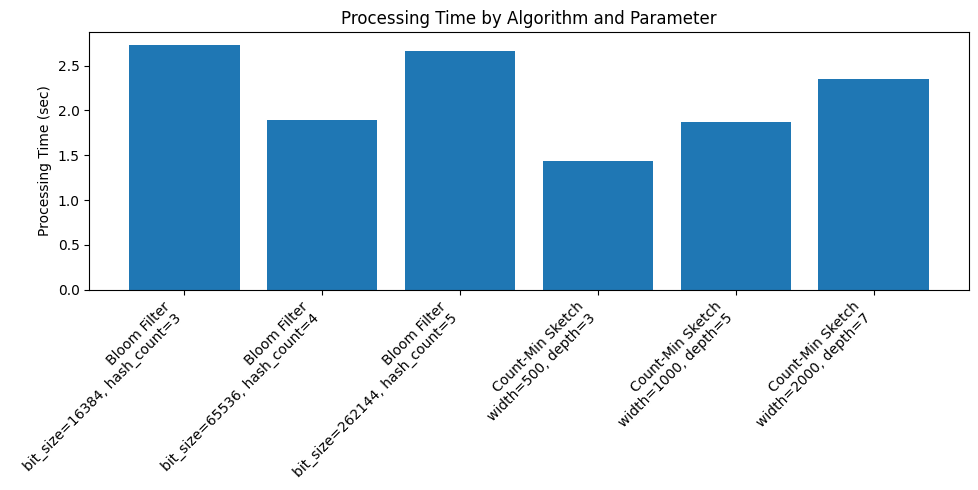

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(plot_df['label'], plot_df['time_sec'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Processing Time (sec)')
plt.title('Processing Time by Algorithm and Parameter')
plt.tight_layout()
plt.show()
